In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

## Depth-averaged ADCP: principal axis + PCU by ebb/flood, and cosine-form tidal cycles

This section uses the depth-averaged ADCP time series (east/north velocities) and the pre-labeled ebb/flood phase file (`depthAvg_ADCPdata_labeled.csv`).

Goals:
- Compute **principal axis** separately for **FLOOD** and **EBB** samples
- Compute **PCU** (projection onto the principal axis) for each phase
- Segment the record into **tidal cycles** and visualize them in a **phase / cosine** form

In [24]:
DEPTHAVG_LABELED_FILE = "depthAvg_ADCPdata_labeled.csv"  # has: Date & Time.2, Eas, Nor, Phase
DEPTHAVG_RAW_FILE = "depthAvg_ADCPdata.csv"              # fallback if labeled is missing
TIME_COL = "Date & Time.2"
E_COL = "Eas"
N_COL = "Nor"
PHASE_COL = "Phase"

# For cycle extraction / smoothing
SLACK_SPEED_THR = 0.05   # m/s; used only if Phase is missing
SMOOTH_N = 3             # samples (10-min data => 30 min smoothing)
MIN_CYCLE_HOURS = 6.0
MAX_CYCLE_HOURS = 18.0

def _load_depthavg_df():
    if os.path.exists(DEPTHAVG_LABELED_FILE):
        df0 = pd.read_csv(DEPTHAVG_LABELED_FILE)
        df0[TIME_COL] = pd.to_datetime(df0[TIME_COL], errors="coerce")
        df0 = df0.dropna(subset=[TIME_COL]).sort_values(TIME_COL).reset_index(drop=True)
        # Ensure floats
        df0[E_COL] = pd.to_numeric(df0[E_COL], errors="coerce")
        df0[N_COL] = pd.to_numeric(df0[N_COL], errors="coerce")
        return df0
    
    # Fallback: raw file is typically mm/s; convert to m/s and classify ebb/flood by principal axis sign
    df0 = pd.read_csv(DEPTHAVG_RAW_FILE)
    df0[TIME_COL] = pd.to_datetime(df0[TIME_COL], errors="coerce")
    df0 = df0.dropna(subset=[TIME_COL]).sort_values(TIME_COL).reset_index(drop=True)
    df0[E_COL] = pd.to_numeric(df0[E_COL], errors="coerce") / 1000.0
    df0[N_COL] = pd.to_numeric(df0[N_COL], errors="coerce") / 1000.0
    return df0

df_avg = _load_depthavg_df()
print(f"Loaded depth-avg data: {df_avg.shape}")
print(f"Columns: {list(df_avg.columns)}")
print(df_avg.head())

Loaded depth-avg data: (16542, 8)
Columns: ['Date & Time.2', 'Eas', 'Nor', 'Mag', 'Dir', 'theta_used_degT', 'u_along_overall', 'phase']
        Date & Time.2    Eas    Nor    Mag     Dir  theta_used_degT  \
0 2024-10-23 09:00:00  0.185  0.069  0.197   64.47            64.47   
1 2024-10-23 09:10:00  0.091  0.046  0.102   57.47            57.47   
2 2024-10-23 09:20:00  0.013  0.034  0.036   14.47            14.47   
3 2024-10-23 09:30:00 -0.079  0.009  0.080  271.47           271.47   
4 2024-10-23 09:40:00 -0.175 -0.001  0.175  264.47           264.47   

   u_along_overall  phase  
0         0.196537  slack  
1         0.099785  slack  
2         0.021329  slack  
3        -0.074006  slack  
4        -0.169338  slack  


In [25]:
def principal_axis_from_EN(E, N):
    """Return (ex, ey, bearing_deg_from_north) for principal axis of (E,N)."""
    E = np.asarray(E, dtype=float)
    N = np.asarray(N, dtype=float)
    good = np.isfinite(E) & np.isfinite(N)
    if good.sum() < 10:
        raise ValueError("Not enough valid samples to compute principal axis.")
    x = np.vstack([E[good] - np.nanmean(E[good]), N[good] - np.nanmean(N[good])])
    C = np.cov(x)
    eigvals, eigvecs = np.linalg.eigh(C)
    e1 = eigvecs[:, np.argmax(eigvals)]
    ex, ey = float(e1[0]), float(e1[1])
    # normalize
    nrm = math.hypot(ex, ey)
    ex, ey = ex/nrm, ey/nrm
    angle_from_east_deg = (math.degrees(math.atan2(ey, ex)) + 360.0) % 360.0  # CCW from East
    bearing_from_north_deg = (90.0 - angle_from_east_deg) % 360.0            # clockwise from North
    return ex, ey, bearing_from_north_deg

def compute_phase_if_missing(df_in):
    """If Phase column missing, create one using a global principal axis + slack threshold."""
    df = df_in.copy()
    if PHASE_COL in df.columns:
        return df
    ex, ey, brg = principal_axis_from_EN(df[E_COL].values, df[N_COL].values)
    u_signed = df[E_COL].values * ex + df[N_COL].values * ey
    u_smooth = pd.Series(u_signed).rolling(window=SMOOTH_N, center=True, min_periods=1).mean().to_numpy()
    phase = np.where(u_smooth > SLACK_SPEED_THR, "FLOOD", np.where(u_smooth < -SLACK_SPEED_THR, "EBB", "SLACK"))
    df[PHASE_COL] = phase
    print(f"Phase was missing; created Phase using global PCA axis bearing={brg:.2f}°T and slack thr=±{SLACK_SPEED_THR:.2f} m/s")
    return df

df_avg = compute_phase_if_missing(df_avg)
df_avg[PHASE_COL] = df_avg[PHASE_COL].astype(str).str.upper()
print(df_avg[PHASE_COL].value_counts(dropna=False))

Phase was missing; created Phase using global PCA axis bearing=255.29°T and slack thr=±0.05 m/s
Phase
FLOOD    8105
EBB      7977
SLACK     460
Name: count, dtype: int64


In [26]:
# --- principal axis & PCU by phase (EBB vs FLOOD) ---
is_flood = df_avg[PHASE_COL].values == "FLOOD"
is_ebb = df_avg[PHASE_COL].values == "EBB"

E = df_avg[E_COL].to_numpy(dtype=float)
N = df_avg[N_COL].to_numpy(dtype=float)
t_avg = df_avg[TIME_COL].to_numpy()

ex_all, ey_all, brg_all = principal_axis_from_EN(E, N)
print(f"Global principal axis bearing: {brg_all:.2f}°T  unit=(E,N)=({ex_all:.4f},{ey_all:.4f})")

ex_f, ey_f, brg_f = principal_axis_from_EN(E[is_flood], N[is_flood])
ex_e, ey_e, brg_e = principal_axis_from_EN(E[is_ebb], N[is_ebb])
print(f"FLOOD principal axis bearing:  {brg_f:.2f}°T  unit=(E,N)=({ex_f:.4f},{ey_f:.4f})")
print(f"EBB principal axis bearing:    {brg_e:.2f}°T  unit=(E,N)=({ex_e:.4f},{ey_e:.4f})")

df_avg["pcu_global"] = E*ex_all + N*ey_all
df_avg["pcu_floodaxis"] = np.where(is_flood, E*ex_f + N*ey_f, np.nan)
df_avg["pcu_ebbaxis"] = np.where(is_ebb, E*ex_e + N*ey_e, np.nan)

# Helpful speeds (magnitudes)
df_avg["pcu_global_speed"] = np.abs(df_avg["pcu_global"].to_numpy(dtype=float))
df_avg["pcu_phase_speed"] = np.where(is_flood, np.abs(df_avg["pcu_floodaxis"].to_numpy(dtype=float)),
                                 np.where(is_ebb, np.abs(df_avg["pcu_ebbaxis"].to_numpy(dtype=float)), np.nan))

def _summ(name, x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        print(f"{name}: no valid samples")
        return
    print(f"{name}: n={x.size}  mean={x.mean():.3f}  p95={np.percentile(x,95):.3f}  max={x.max():.3f}")

print("\nPCU speed summaries (m/s)")
_summ("Global |pcu|", df_avg["pcu_global_speed"].values)
_summ("FLOOD |pcu| (flood-axis)", np.abs(df_avg["pcu_floodaxis"].values))
_summ("EBB |pcu| (ebb-axis)", np.abs(df_avg["pcu_ebbaxis"].values))

Global principal axis bearing: 255.29°T  unit=(E,N)=(-0.9672,-0.2539)
FLOOD principal axis bearing:  254.70°T  unit=(E,N)=(-0.9645,-0.2639)
EBB principal axis bearing:    256.43°T  unit=(E,N)=(-0.9721,-0.2346)

PCU speed summaries (m/s)
Global |pcu|: n=16542  mean=0.708  p95=1.202  max=1.564
FLOOD |pcu| (flood-axis): n=8105  mean=0.742  p95=1.236  max=1.562
EBB |pcu| (ebb-axis): n=7977  mean=0.711  p95=1.173  max=1.494


In [27]:
# --- segment into contiguous ebb/flood events, compute per-event axis & PCU stats ---
phase = df_avg[PHASE_COL].values
event_id = np.full(len(df_avg), -1, dtype=int)
event_phase = []
event_slices = []

eid = -1
in_event = False
current_phase = None
start_i = None
for i, ph in enumerate(phase):
    if ph in ("EBB", "FLOOD"):
        if (not in_event) or (ph != current_phase):
            # close previous event
            if in_event:
                event_phase.append(current_phase)
                event_slices.append(slice(start_i, i))
            # start new
            eid += 1
            in_event = True
            current_phase = ph
            start_i = i
        event_id[i] = eid
    else:
        # slack / unknown closes event
        if in_event:
            event_phase.append(current_phase)
            event_slices.append(slice(start_i, i))
            in_event = False
            current_phase = None
            start_i = None

# close final
if in_event:
    event_phase.append(current_phase)
    event_slices.append(slice(start_i, len(df_avg)))

df_avg["event_id"] = event_id
print(f"Detected events: {len(event_slices)} (ebb/flood segments separated by slack)")

rows = []
for k, sl in enumerate(event_slices):
    ph = event_phase[k]
    Ei = E[sl]
    Ni = N[sl]
    ti = df_avg[TIME_COL].iloc[sl].to_numpy()
    if len(ti) < 5:
        continue
    exk, eyk, brgk = principal_axis_from_EN(Ei, Ni)
    pcu_k = Ei*exk + Ni*eyk
    dur_hr = (pd.to_datetime(ti[-1]) - pd.to_datetime(ti[0])).total_seconds()/3600.0
    rows.append({
        "event_id": k,
        "phase": ph,
        "start": pd.to_datetime(ti[0]),
        "end": pd.to_datetime(ti[-1]),
        "duration_hr": dur_hr,
        "axis_bearing_degT": brgk,
        "pcu_rms_mps": float(np.sqrt(np.nanmean(pcu_k**2))),
        "pcu_max_abs_mps": float(np.nanmax(np.abs(pcu_k))),
        "n": int(np.isfinite(pcu_k).sum()),
    })

events = pd.DataFrame(rows)
events.head()

Detected events: 446 (ebb/flood segments separated by slack)


,event_id,phase,start,end,duration_hr,axis_bearing_degT,pcu_rms_mps,pcu_max_abs_mps,n
0,1,FLOOD,2024-10-23 09:30:00,2024-10-23 15:40:00,6.166667,260.103881,0.747133,1.048369,38
1,2,EBB,2024-10-23 16:00:00,2024-10-23 22:10:00,6.166667,262.346463,0.704493,1.002400,38
2,3,FLOOD,2024-10-23 22:30:00,2024-10-24 04:30:00,6.000000,261.470266,0.688735,0.950467,37
3,4,EBB,2024-10-24 04:50:00,2024-10-24 10:30:00,5.666667,262.876264,0.644059,0.892057,35
4,5,FLOOD,2024-10-24 11:00:00,2024-10-24 16:50:00,5.833333,261.536879,0.655355,0.888249,36


Upward zero-crossings found: 223
Cycles kept (duration 6.0-18.0 hr): 222
Cosine fit to mean cycle: amplitude=1.100 m/s, phase_shift≈88.1°
Cycle plot x-axis span: 2024-10-23 09:30:00 to 2024-10-23 21:55:14.864864865 (mean duration=12.42 h)


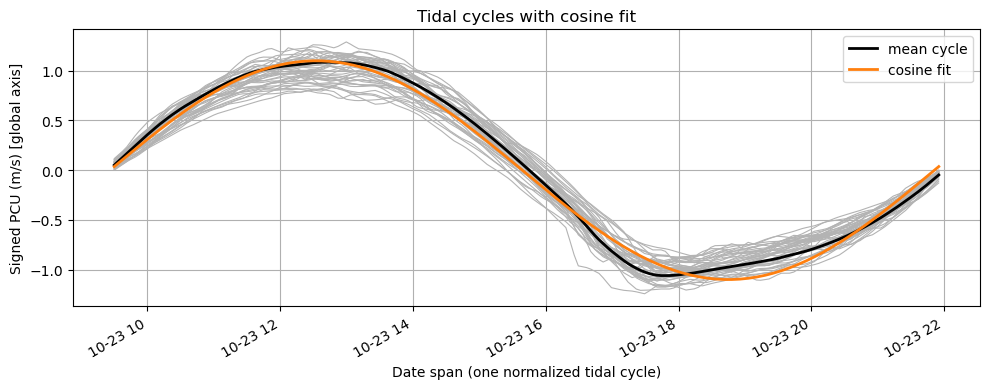

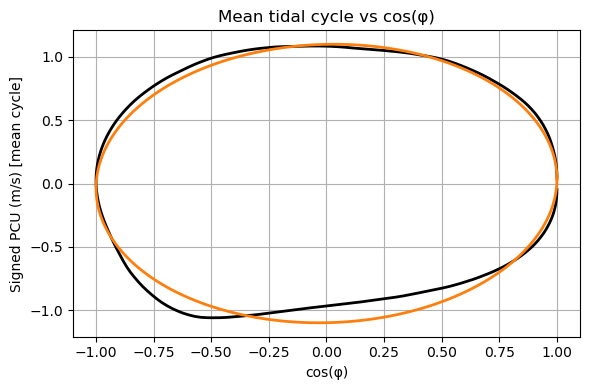

In [28]:
# --- build full tidal cycles (between upward zero-crossings) and plot in date-span/cosine form ---
def _find_upward_zero_crossings(u_signed, time_values):
    """Return indices i where u[i] <= 0 and u[i+1] > 0 (upward crossing)."""
    u = np.asarray(u_signed, dtype=float)
    good = np.isfinite(u)
    u = np.where(good, u, np.nan)
    idx = []
    for i in range(len(u) - 1):
        if np.isfinite(u[i]) and np.isfinite(u[i+1]) and (u[i] <= 0) and (u[i+1] > 0):
            idx.append(i)
    return np.array(idx, dtype=int)

# Use a smoothed signed series for cycle finding
u_for_cycles = pd.Series(df_avg["pcu_global"].values).rolling(window=SMOOTH_N, center=True, min_periods=1).mean().to_numpy()
cross = _find_upward_zero_crossings(u_for_cycles, t_avg)
print(f"Upward zero-crossings found: {len(cross)}")

# Create cycles between successive upward crossings
cycles = []
for a, b in zip(cross[:-1], cross[1:]):
    i0 = a + 1
    i1 = b + 1
    if i1 - i0 < 10:
        continue
    t0 = pd.to_datetime(df_avg[TIME_COL].iloc[i0])
    t1 = pd.to_datetime(df_avg[TIME_COL].iloc[i1])
    dur_hr = (t1 - t0).total_seconds()/3600.0
    if (dur_hr < MIN_CYCLE_HOURS) or (dur_hr > MAX_CYCLE_HOURS):
        continue
    cycles.append((i0, i1, dur_hr))

print(f"Cycles kept (duration {MIN_CYCLE_HOURS}-{MAX_CYCLE_HOURS} hr): {len(cycles)}")

# Resample each cycle onto a common phase grid 0..2π
n_phase = 200
phi_grid = np.linspace(0, 2*np.pi, n_phase)
U_mat = np.full((len(cycles), n_phase), np.nan)
for k, (i0, i1, dur_hr) in enumerate(cycles):
    tseg = pd.to_datetime(df_avg[TIME_COL].iloc[i0:i1]).astype("int64").to_numpy(dtype=float)
    tseg = (tseg - tseg[0]) / (tseg[-1] - tseg[0])  # 0..1
    useg = df_avg["pcu_global"].iloc[i0:i1].to_numpy(dtype=float)
    good = np.isfinite(useg) & np.isfinite(tseg)
    if good.sum() < 10:
        continue
    # Interpolate onto phase grid (in 0..1 then map to 0..2π)
    x = tseg[good]
    y = useg[good]
    xg = phi_grid / (2*np.pi)
    U_mat[k, :] = np.interp(xg, x, y)

U_mean = np.nanmean(U_mat, axis=0)
U_std = np.nanstd(U_mat, axis=0)

# Fit mean cycle to u(φ) = a cos φ + b sin φ (least squares)
A = np.vstack([np.cos(phi_grid), np.sin(phi_grid)]).T
goodm = np.isfinite(U_mean)
coef, *_ = np.linalg.lstsq(A[goodm], U_mean[goodm], rcond=None)
a, b = float(coef[0]), float(coef[1])
U_fit = a*np.cos(phi_grid) + b*np.sin(phi_grid)
amp = math.hypot(a, b)
phase_shift = math.degrees(math.atan2(b, a))  # u ≈ amp*cos(φ - shift) with shift=atan2(b,a)
print(f"Cosine fit to mean cycle: amplitude={amp:.3f} m/s, phase_shift≈{phase_shift:.1f}°")

# Build a representative datetime span for one normalized cycle
if len(cycles) > 0:
    mean_cycle_hr = float(np.nanmean([c[2] for c in cycles]))
    span_start = pd.to_datetime(df_avg[TIME_COL].iloc[cycles[0][0]])
    span_end = span_start + pd.to_timedelta(mean_cycle_hr, unit="h")
    t_span = pd.date_range(span_start, span_end, periods=n_phase)
    print(f"Cycle plot x-axis span: {span_start} to {span_end} (mean duration={mean_cycle_hr:.2f} h)")
else:
    t_span = None

# Plot: spaghetti + mean + cosine fit (x-axis as date span)
plt.figure(figsize=(10,4))
for k in range(min(U_mat.shape[0], 40)):
    if t_span is not None:
        plt.plot(t_span, U_mat[k,:], color="0.7", linewidth=0.8)
    else:
        plt.plot(phi_grid, U_mat[k,:], color="0.7", linewidth=0.8)
if t_span is not None:
    plt.plot(t_span, U_mean, color="k", linewidth=2, label="mean cycle")
    plt.plot(t_span, U_fit, color="C1", linewidth=2, label="cosine fit")
    plt.xlabel("Date span (one normalized tidal cycle)")
    plt.gcf().autofmt_xdate()
else:
    plt.plot(phi_grid, U_mean, color="k", linewidth=2, label="mean cycle")
    plt.plot(phi_grid, U_fit, color="C1", linewidth=2, label="cosine fit")
    plt.xlabel("Phase φ (rad)")
plt.ylabel("Signed PCU (m/s) [global axis]")
plt.title("Tidal cycles with cosine fit")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Optional: cosine-form x-axis (cos φ) representation
plt.figure(figsize=(6,4))
plt.plot(np.cos(phi_grid), U_mean, color="k", linewidth=2)
plt.plot(np.cos(phi_grid), U_fit, color="C1", linewidth=2)
plt.xlabel("cos(φ)")
plt.ylabel("Signed PCU (m/s) [mean cycle]")
plt.title("Mean tidal cycle vs cos(φ)")
plt.grid(True)
plt.tight_layout()
plt.show()

## Peak Flood/Ebb Depth Profiles with Roughness-Aware Power-Law Fits

This section fits peak flood and ebb profiles using the roughness-aware form:

$$
\overline{u}(z)=\left(\frac{z}{\beta h}\right)^{\frac{1}{\alpha}}U
$$

where:
- $\overline{u}(z)$ is streamwise velocity (m/s)
- $z$ is height above bed (m)
- $U$ is depth-averaged velocity (m/s)
- $h$ is water depth (m)
- $\alpha$ is the power exponent
- $\beta$ is the bed roughness coefficient

Using $\eta=z/h$, the fitted form is:

$$
\frac{\overline{u}}{U}=\left(\frac{\eta}{\beta}\right)^{\frac{1}{\alpha}}
$$

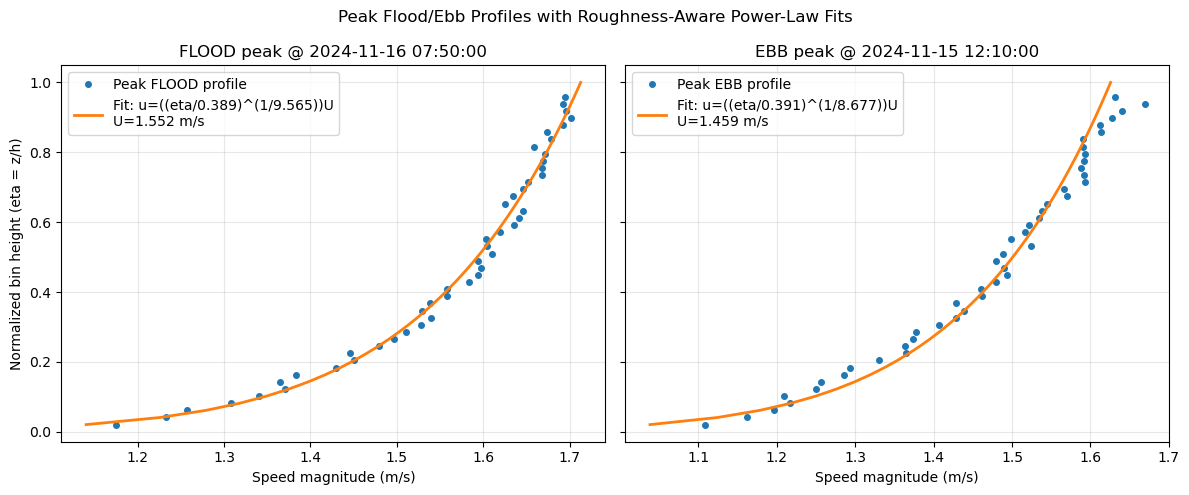

Roughness-aware fit summary: u = ((z/(beta*h))^(1/alpha)) * U
Phase           Peak_time  Peak_profile_max_mps  Depth_avg_U_mps    alpha     beta  fit_points
FLOOD 2024-11-16 07:50:00                 1.702            1.552 9.565237 0.389267          47
  EBB 2024-11-15 12:10:00                 1.669            1.459 8.677322 0.391031          47


In [29]:
# Peak flood/ebb depth profiles and roughness-aware power-law fits
DEPTHDEP_FILE = "depthDep_ADCPdata.csv"
PHASE_FILE = "depthAvg_ADCPdata_labeled.csv"
DEPTHDEP_TIME_COL = "DateTime"
PHASE_TIME_COL = "Date & Time.2"
PHASE_VALUE_COL = "phase"

# depth-dependent file has a two-row header: (bin_number, component)
dd_raw = pd.read_csv(DEPTHDEP_FILE, header=[0, 1])

# Find the time column (first-level header usually "DateTime").
time_col = None
for col in dd_raw.columns:
    h0 = str(col[0]).strip().lower()
    if h0 in {"datetime", "date & time.2", "date&time.2"}:
        time_col = col
        break
if time_col is None:
    raise KeyError("Could not find a datetime column in depthDep_ADCPdata.csv")

mag_pairs = []
for col in dd_raw.columns:
    lvl0 = str(col[0]).strip()
    lvl1 = str(col[1]).strip().lower()
    if lvl1 != "mag":
        continue
    try:
        bin_id = float(lvl0)
    except ValueError:
        continue
    mag_pairs.append((bin_id, col))

if not mag_pairs:
    raise ValueError("No Mag columns found in depthDep_ADCPdata.csv")

mag_pairs = sorted(mag_pairs, key=lambda x: x[0])
profile_cols = [f"bin_{int(round(b)):02d}" for b, _ in mag_pairs]

# Build a flat table with m/s magnitudes.
dd = pd.DataFrame({"time": pd.to_datetime(dd_raw[time_col], errors="coerce")})
for (_, col), out_col in zip(mag_pairs, profile_cols):
    dd[out_col] = pd.to_numeric(dd_raw[col], errors="coerce") / 1000.0

dd = dd.dropna(subset=["time"]).sort_values("time").reset_index(drop=True)

phase_df = pd.read_csv(PHASE_FILE)
phase_df["time"] = pd.to_datetime(phase_df[PHASE_TIME_COL], errors="coerce")
phase_df["phase"] = phase_df[PHASE_VALUE_COL].astype(str).str.upper().str.strip()

u_col = next((c for c in phase_df.columns if str(c).strip().lower() == "mag"), None)
if u_col is None:
    raise KeyError("Could not find depth-averaged velocity column 'Mag' in phase file")
phase_df["U_mps"] = pd.to_numeric(phase_df[u_col], errors="coerce")
phase_df = phase_df.dropna(subset=["time"]).sort_values("time")

merged = pd.merge_asof(
    dd,
    phase_df[["time", "phase", "U_mps"]],
    on="time",
    direction="nearest",
    tolerance=pd.Timedelta("6min"),
)
merged = merged[merged["phase"].isin(["FLOOD", "EBB"])].copy()

if merged.empty:
    raise ValueError("No flood/ebb-matched depth profiles found after time merge")

bin_numbers = np.array([int(c.split("_")[1]) for c in profile_cols], dtype=float)
eta = bin_numbers / bin_numbers.max()  # eta = z/h

def get_peak_profile(df_phase):
    row_max = df_phase[profile_cols].max(axis=1, skipna=True)
    idx = row_max.idxmax()
    u_peak = pd.to_numeric(df_phase.loc[idx, profile_cols], errors="coerce").to_numpy(dtype=float)
    t_peak = pd.to_datetime(df_phase.loc[idx, "time"])
    u_peak_max = float(row_max.loc[idx])
    U_depthavg = float(pd.to_numeric(pd.Series([df_phase.loc[idx, "U_mps"]]), errors="coerce").iloc[0])
    if not np.isfinite(U_depthavg) or U_depthavg <= 0:
        U_depthavg = float(np.nanmean(u_peak))
    return u_peak, t_peak, u_peak_max, U_depthavg

def fit_roughness_power_law(eta_in, u_in, U_in):
    # log(u/U) = (1/alpha) * log(eta) - (1/alpha) * log(beta)
    eta_in = np.asarray(eta_in, dtype=float)
    u_in = np.asarray(u_in, dtype=float)
    mask = np.isfinite(eta_in) & np.isfinite(u_in) & (eta_in > 0) & (u_in > 0) & np.isfinite(U_in) & (U_in > 0)
    if mask.sum() < 3:
        raise ValueError("Not enough valid points to fit roughness-aware power law")

    x = np.log(eta_in[mask])
    y = np.log(u_in[mask] / U_in)
    slope, intercept = np.polyfit(x, y, 1)

    if np.isclose(slope, 0.0):
        raise ValueError("Slope too small to estimate alpha and beta")

    alpha = float(1.0 / slope)
    beta = float(np.exp(-intercept / slope))

    u_fit = U_in * ((eta_in / beta) ** (1.0 / alpha))
    return alpha, beta, u_fit, int(mask.sum())

flood_df = merged[merged["phase"] == "FLOOD"]
ebb_df = merged[merged["phase"] == "EBB"]
if flood_df.empty or ebb_df.empty:
    raise ValueError("Need both FLOOD and EBB samples for this plot")

u_flood, t_flood, u_flood_max, U_flood = get_peak_profile(flood_df)
u_ebb, t_ebb, u_ebb_max, U_ebb = get_peak_profile(ebb_df)

alpha_f, beta_f, ufit_f, nfit_f = fit_roughness_power_law(eta, u_flood, U_flood)
alpha_e, beta_e, ufit_e, nfit_e = fit_roughness_power_law(eta, u_ebb, U_ebb)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].plot(u_flood, eta, "o", ms=4, label="Peak FLOOD profile")
axes[0].plot(
    ufit_f,
    eta,
    "-",
    lw=2,
    label=f"Fit: u=((eta/{beta_f:.3f})^(1/{alpha_f:.3f}))U\nU={U_flood:.3f} m/s",
)
axes[0].set_title(f"FLOOD peak @ {t_flood}")
axes[0].set_xlabel("Speed magnitude (m/s)")
axes[0].set_ylabel("Normalized bin height (eta = z/h)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(u_ebb, eta, "o", ms=4, label="Peak EBB profile")
axes[1].plot(
    ufit_e,
    eta,
    "-",
    lw=2,
    label=f"Fit: u=((eta/{beta_e:.3f})^(1/{alpha_e:.3f}))U\nU={U_ebb:.3f} m/s",
)
axes[1].set_title(f"EBB peak @ {t_ebb}")
axes[1].set_xlabel("Speed magnitude (m/s)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.suptitle("Peak Flood/Ebb Profiles with Roughness-Aware Power-Law Fits")
plt.tight_layout()
plt.show()

print("Roughness-aware fit summary: u = ((z/(beta*h))^(1/alpha)) * U")
fit_summary = pd.DataFrame(
    {
        "Phase": ["FLOOD", "EBB"],
        "Peak_time": [t_flood, t_ebb],
        "Peak_profile_max_mps": [u_flood_max, u_ebb_max],
        "Depth_avg_U_mps": [U_flood, U_ebb],
        "alpha": [alpha_f, alpha_e],
        "beta": [beta_f, beta_e],
        "fit_points": [nfit_f, nfit_e],
    }
)
print(fit_summary.to_string(index=False))

## Profile Shape and Flow-Regime Classification

Measured profiles are classified into shape classes using the vertical gradient $\partial u/\partial z$:

- (a) monotonic: $\partial u/\partial z > 0$
- (b) non-monotonic (concave): gradient changes from positive to negative
- (c) pseudo-depth-uniform: $\partial u/\partial z \approx 0$
- (d) non-monotonic (convex): gradient changes from negative to positive
- (e) mixed/negative-gradient: predominantly $\partial u/\partial z < 0$ or multiple sign changes

Flow regime is classified from profile-speed acceleration $a$ (m/s/hour):

- quasi-steady: $|a| < 0.1$
- accelerating: $a > 0.1$
- decelerating: $a < -0.1$

Classification thresholds:
  Shape gradient tolerance: |du/dz| <= 0.030 m/s per eta -> pseudo-depth-uniform
  Regime acceleration thresholds: quasi-steady if |a| < 0.1 m/s/hour

Counts by phase, regime, and profile class:
phase       regime shape_code             shape_class  count
  EBB accelerating          a               monotonic     87
  EBB accelerating          b non-monotonic (concave)     52
  EBB accelerating          e mixed/negative-gradient   1573
  EBB decelerating          a               monotonic    109
  EBB decelerating          b non-monotonic (concave)     46
  EBB decelerating          e mixed/negative-gradient   3151
  EBB quasi-steady          a               monotonic     47
  EBB quasi-steady          b non-monotonic (concave)     27
  EBB quasi-steady          e mixed/negative-gradient   1175
FLOOD accelerating          a               monotonic      1
FLOOD accelerating          b non-monotonic (concave)     14
FLOOD accelerating          e mixed/negative-g

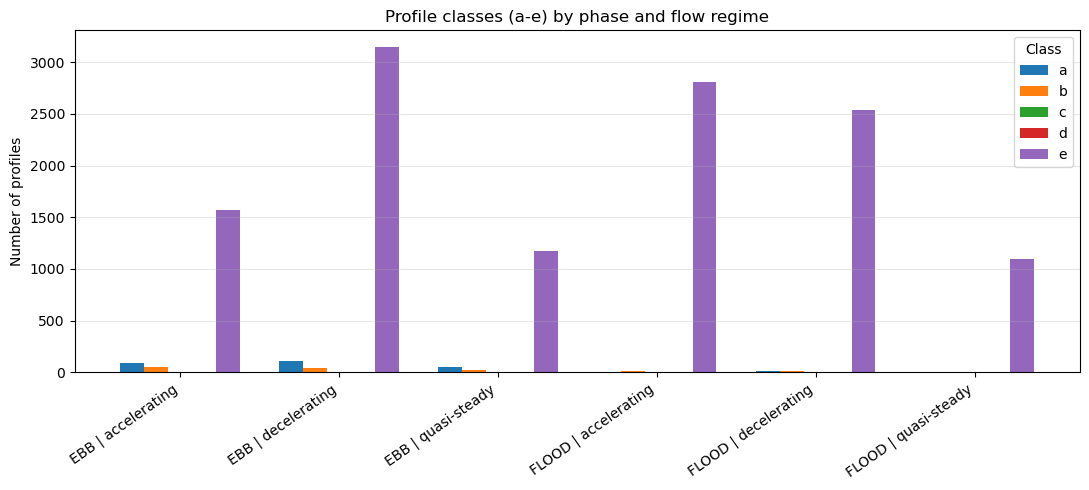

In [30]:
# Classify profile shape and regime for each measured profile

if "merged" not in globals() or "profile_cols" not in globals() or "eta" not in globals():
    raise NameError("Run Cell 11 first to build merged profile data (merged, profile_cols, eta).")

profiles_cls = merged[["time", "phase"] + profile_cols].copy()
profiles_cls = profiles_cls.sort_values("time").reset_index(drop=True)

# Use depth-mean profile speed as a representative profile speed
profiles_cls["profile_speed_mps"] = profiles_cls[profile_cols].mean(axis=1, skipna=True)

# Compute acceleration a = dU/dt in m/s/hour using central differences
t_num = (pd.to_datetime(profiles_cls["time"]) - pd.to_datetime(profiles_cls["time"]).iloc[0]).dt.total_seconds().to_numpy() / 3600.0
U = profiles_cls["profile_speed_mps"].to_numpy(dtype=float)

if np.isfinite(U).sum() < 3:
    raise ValueError("Not enough valid profile speeds to compute acceleration")

U_fill = pd.Series(U).interpolate(limit_direction="both").to_numpy(dtype=float)
a_prof = np.gradient(U_fill, t_num)
profiles_cls["accel_mps_per_hr"] = a_prof

# Regime classification thresholds
ACC_THR = 0.1
profiles_cls["regime"] = np.where(
    profiles_cls["accel_mps_per_hr"] > ACC_THR,
    "accelerating",
    np.where(profiles_cls["accel_mps_per_hr"] < -ACC_THR, "decelerating", "quasi-steady"),
)

# Shape classification based on du/dz sign behavior
# z is represented by eta=z/h; derivative scaling by h does not change sign
SHAPE_TOL = 0.03  # m/s per eta

def classify_profile_shape(u_vals, z_vals, tol=SHAPE_TOL):
    u_vals = np.asarray(u_vals, dtype=float)
    z_vals = np.asarray(z_vals, dtype=float)
    good = np.isfinite(u_vals) & np.isfinite(z_vals)
    if good.sum() < 3:
        return "c", "pseudo-depth-uniform"

    u = u_vals[good]
    z = z_vals[good]
    du_dz = np.gradient(u, z)

    # Ignore near-zero gradients for sign-change logic
    strong = np.abs(du_dz) > tol
    if strong.sum() == 0:
        return "c", "pseudo-depth-uniform"

    s = np.sign(du_dz[strong])
    if np.all(s > 0):
        return "a", "monotonic"
    if np.all(s < 0):
        return "e", "mixed/negative-gradient"

    has_pos_to_neg = np.any((s[:-1] > 0) & (s[1:] < 0))
    has_neg_to_pos = np.any((s[:-1] < 0) & (s[1:] > 0))

    if has_pos_to_neg and not has_neg_to_pos:
        return "b", "non-monotonic (concave)"
    if has_neg_to_pos and not has_pos_to_neg:
        return "d", "non-monotonic (convex)"
    return "e", "mixed/negative-gradient"

shape_code = []
shape_label = []
for _, row in profiles_cls.iterrows():
    code, label = classify_profile_shape(row[profile_cols].to_numpy(dtype=float), eta)
    shape_code.append(code)
    shape_label.append(label)

profiles_cls["shape_code"] = shape_code
profiles_cls["shape_class"] = shape_label

# Reporting tables
print("Classification thresholds:")
print(f"  Shape gradient tolerance: |du/dz| <= {SHAPE_TOL:.3f} m/s per eta -> pseudo-depth-uniform")
print(f"  Regime acceleration thresholds: quasi-steady if |a| < {ACC_THR:.1f} m/s/hour")

summary_counts = (
    profiles_cls.groupby(["phase", "regime", "shape_code", "shape_class"], dropna=False)
    .size()
    .reset_index(name="count")
    .sort_values(["phase", "regime", "shape_code"])
)
print("\nCounts by phase, regime, and profile class:")
print(summary_counts.to_string(index=False))

summary_pct = summary_counts.copy()
summary_pct["pct_within_phase_regime"] = (
    100.0 * summary_pct["count"] / summary_pct.groupby(["phase", "regime"])["count"].transform("sum")
)
summary_pct["pct_within_phase_regime"] = summary_pct["pct_within_phase_regime"].round(1)
print("\nPercent within each phase-regime bin:")
print(summary_pct.to_string(index=False))

# Pivoted matrix for quick scanning
pivot_counts = profiles_cls.pivot_table(
    index=["phase", "regime"],
    columns="shape_code",
    values="time",
    aggfunc="count",
    fill_value=0,
)

# Ensure a-e order in output
for c in ["a", "b", "c", "d", "e"]:
    if c not in pivot_counts.columns:
        pivot_counts[c] = 0
pivot_counts = pivot_counts[["a", "b", "c", "d", "e"]]
print("\nPivot counts (columns a-e):")
print(pivot_counts.to_string())

# Visual summary by regime and phase
plot_df = summary_counts.copy()
plot_df["class"] = plot_df["shape_code"] + ": " + plot_df["shape_class"]

fig, ax = plt.subplots(figsize=(11, 5))
for i, (phase_name, grp) in enumerate(plot_df.groupby("phase")):
    x = np.arange(len(grp)) + i * 0.35

# Simpler grouped bar from pivot table
pivot_plot = pivot_counts.reset_index()
pivot_plot["phase_regime"] = pivot_plot["phase"] + " | " + pivot_plot["regime"]
x = np.arange(len(pivot_plot))
width = 0.15
classes = ["a", "b", "c", "d", "e"]
for j, cls in enumerate(classes):
    ax.bar(x + (j - 2) * width, pivot_plot[cls], width=width, label=cls)

ax.set_xticks(x)
ax.set_xticklabels(pivot_plot["phase_regime"], rotation=35, ha="right")
ax.set_ylabel("Number of profiles")
ax.set_title("Profile classes (a-e) by phase and flow regime")
ax.legend(title="Class")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Keep final classified table available for downstream analysis/export
classified_profiles = profiles_cls.copy()